# 6CS012 - Artificial Intelligence and Machine Learning
## Worksheet 1 - Image Compression and Decompression using PCA.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Importing Libraries

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

## Exercise 1

### Task 1 - Read and Display the Image

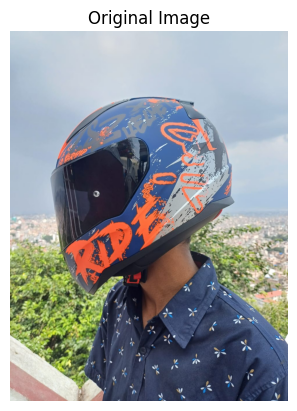

Image shape: (1280, 960, 3)


In [5]:
img_path = "/content/drive/MyDrive/Artificial Intelligence and Machine Learning /MyPhoto.jpg"

picture = Image.open(img_path).convert("RGB")
pic = np.array(picture)

plt.imshow(pic)
plt.title("Original Image")
plt.axis("off")
plt.show()

print("Image shape:", pic.shape)

### Task 2 - Top Left Corner (100x100 pixels)

Using NumPy array slicing to extract just the top left 100x100 region of the image.

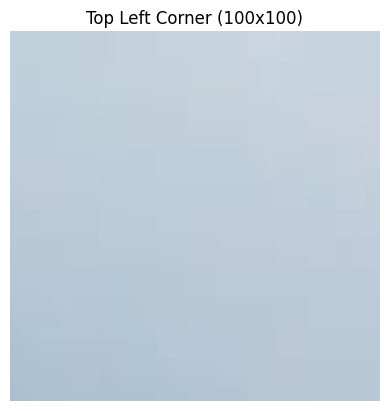

In [6]:
corner = pic[:100, :100]

plt.imshow(corner)
plt.title("Top Left Corner (100x100)")
plt.axis("off")
plt.show()

### Task 3 - Separating R, G, B Channels

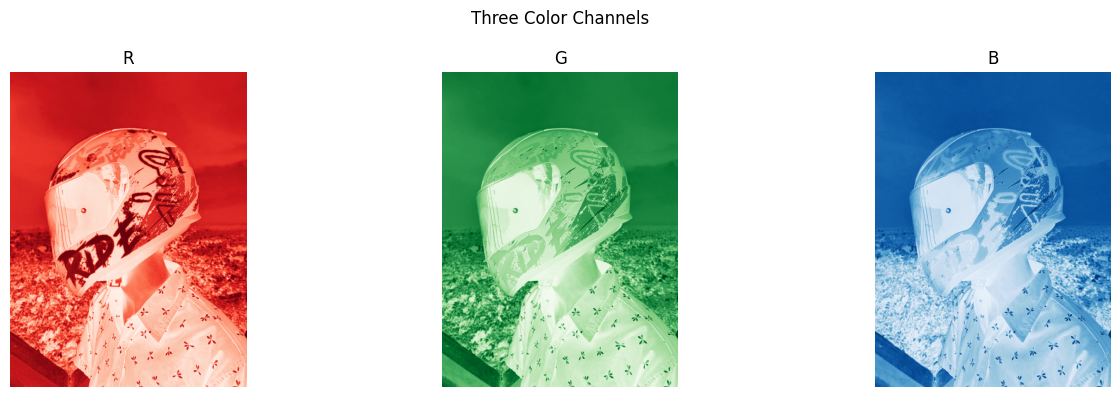

In [7]:
r = pic[:, :, 0]
g = pic[:, :, 1]
b = pic[:, :, 2]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].imshow(r, cmap="Reds")
axes[0].set_title("R")
axes[0].axis("off")

axes[1].imshow(g, cmap="Greens")
axes[1].set_title("G")
axes[1].axis("off")

axes[2].imshow(b, cmap="Blues")
axes[2].set_title("B")
axes[2].axis("off")

plt.suptitle("Three Color Channels")
plt.tight_layout()
plt.show()

### Task 4 - Modify Top 100x100 Pixels to Value 210

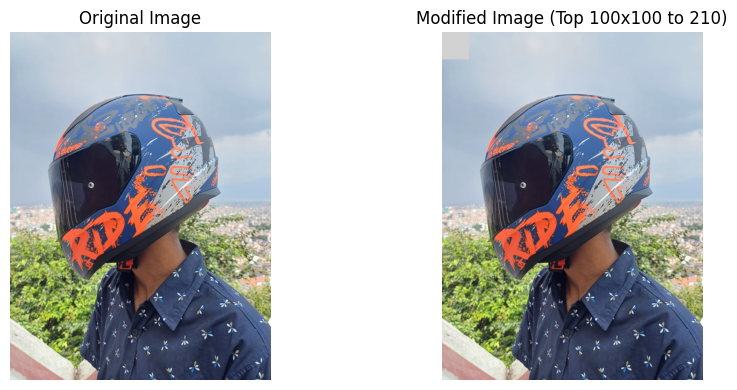

In [8]:
edited_pic = pic.copy()
edited_pic[:100, :100] = 210

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].imshow(pic)
axes[0].set_title("Original Image")
axes[0].axis("off")

axes[1].imshow(edited_pic)
axes[1].set_title("Modified Image (Top 100x100 to 210)")
axes[1].axis("off")

plt.tight_layout()
plt.show()

## Exercise 2 - Grayscale Image Operations

### Task 1 - Load and Display Grayscale Image

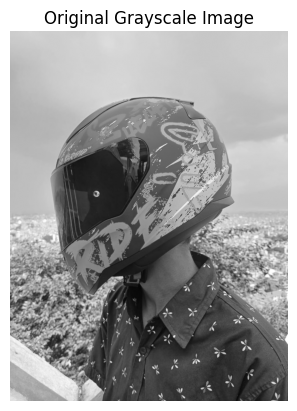

Grayscale image shape: (1280, 960)


In [9]:
gray_pic = Image.open(img_path).convert("L")
gray = np.array(gray_pic)

plt.imshow(gray, cmap="gray")
plt.title("Original Grayscale Image")
plt.axis("off")
plt.show()

print("Grayscale image shape:", gray.shape)

### Task 2 - Extract Middle 150x150 Section

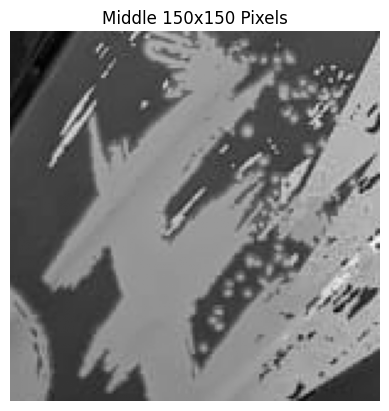

In [10]:
rows, cols = gray.shape
mid_row = rows // 2
mid_col = cols // 2

middle = gray[mid_row - 75 : mid_row + 75, mid_col - 75 : mid_col + 75]

plt.imshow(middle, cmap="gray")
plt.title("Middle 150x150 Pixels")
plt.axis("off")
plt.show()

### Task 3 - Apply Threshold (below 100 to 0, above 100 to 255)

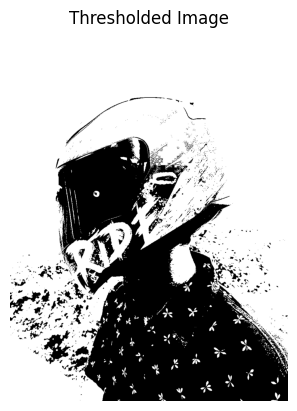

In [11]:
binary = gray.copy()
binary[binary < 100] = 0
binary[binary >= 100] = 255

plt.imshow(binary, cmap="gray")
plt.title("Thresholded Image")
plt.axis("off")
plt.show()

### Task 4 - Rotate Image 90 Degrees Clockwise

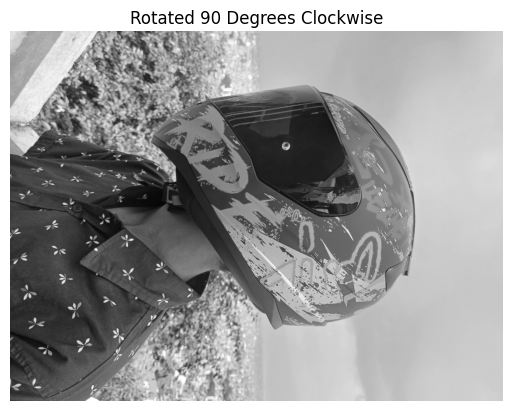

In [12]:
rotated = gray_pic.rotate(-90, expand=True)
rotated_arr = np.array(rotated)

plt.imshow(rotated_arr, cmap="gray")
plt.title("Rotated 90 Degrees Clockwise")
plt.axis("off")
plt.show()

### Task 5 - Convert Grayscale to RGB

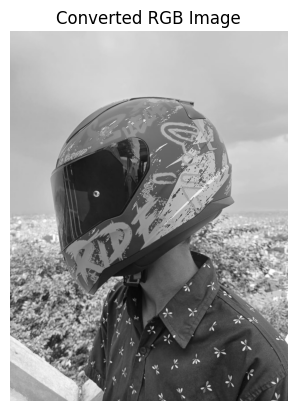

RGB image shape: (1280, 960, 3)


In [13]:
rgb_from_gray = np.stack([gray, gray, gray], axis=2)

plt.imshow(rgb_from_gray)
plt.title("Converted RGB Image")
plt.axis("off")
plt.show()

print("RGB image shape:", rgb_from_gray.shape)

## Exercise 3 - Image Compression using PCA

### Step 1 - Load Image and Standardise the Data

In [23]:
pca_image = Image.open(img_path).convert("L")
img_data = np.array(pca_image, dtype=np.float64)

print("Image shape:", img_data.shape)

col_mean = np.mean(img_data, axis=0)
col_std = np.std(img_data, axis=0)
col_std[col_std == 0] = 1

img_centered = (img_data - col_mean) / col_std

cov = np.cov(img_centered, rowvar=False)
print("Covariance matrix shape:", cov.shape)

Image shape: (1280, 960)
Covariance matrix shape: (960, 960)


### Step 2 - Eigen Decomposition and Identifying Principal Components

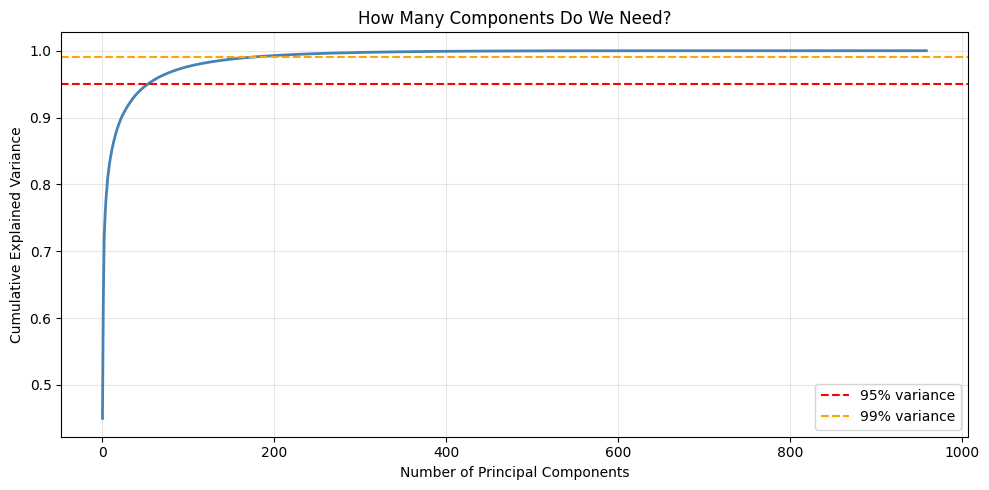

80% variance needs 7 components
90% variance needs 24 components
95% variance needs 54 components
99% variance needs 172 components


In [24]:
eig_vals, eig_vecs = np.linalg.eigh(cov)

order = np.argsort(eig_vals)[::-1]
eig_vals = eig_vals[order]
eig_vecs = eig_vecs[:, order]

var_ratio = eig_vals / np.sum(eig_vals)
cumulative = np.cumsum(var_ratio)

plt.figure(figsize=(10, 5))
plt.plot(cumulative, color='steelblue', linewidth=2)
plt.axhline(y=0.95, color='red', linestyle='--', label='95% variance')
plt.axhline(y=0.99, color='orange', linestyle='--', label='99% variance')
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("How Many Components Do We Need?")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

for t in [0.80, 0.90, 0.95, 0.99]:
    n_components = np.searchsorted(cumulative, t) + 1
    print(f"{int(t * 100)}% variance needs {n_components} components")

### Step 3 - Reconstruction and Experiments

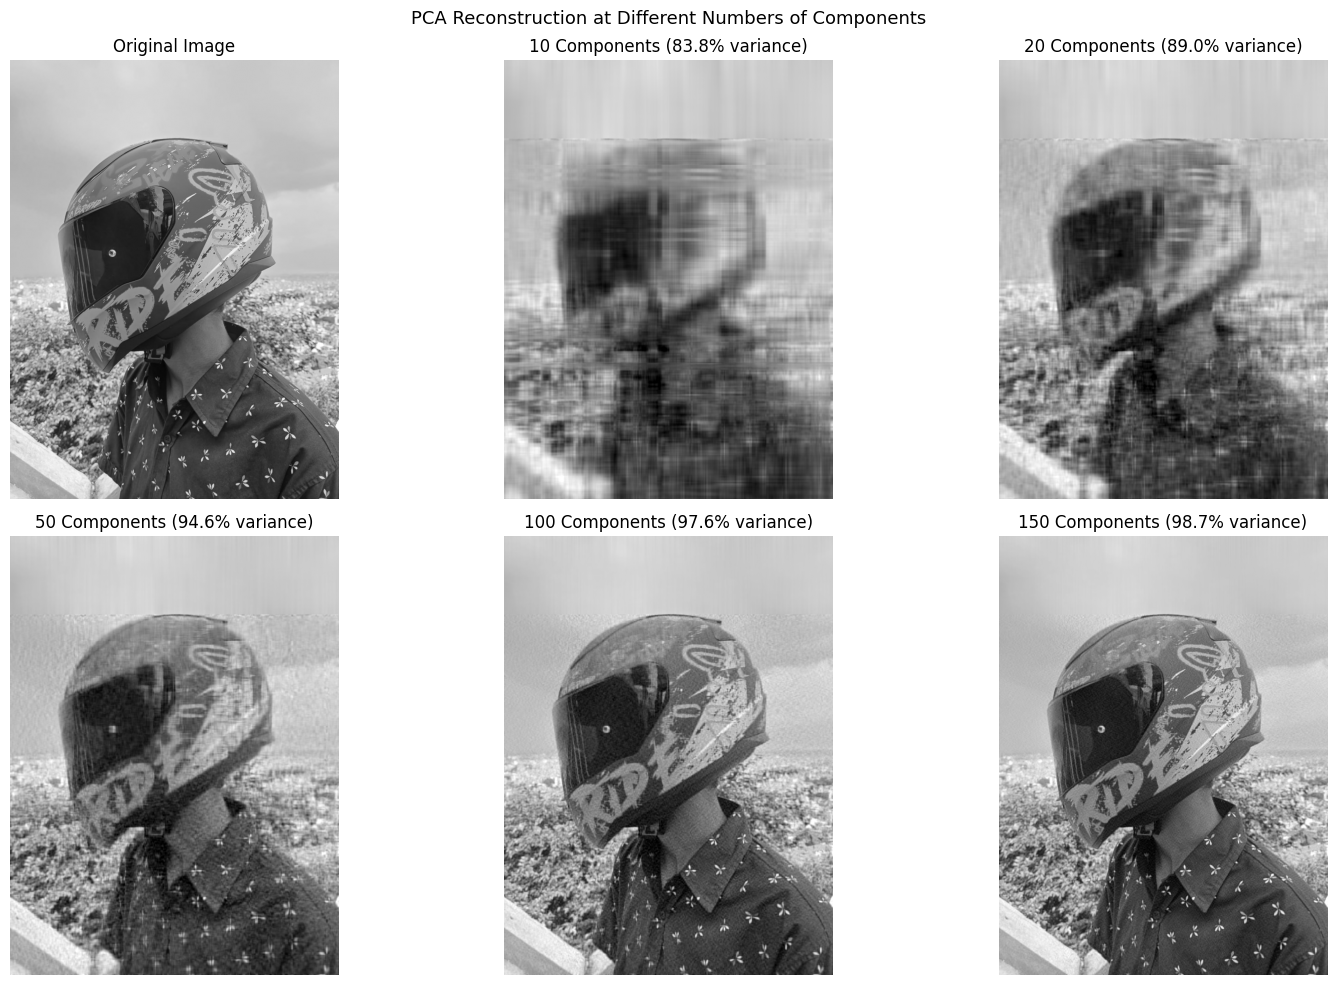

In [29]:
def rebuild_image(centered_data, vecs, k, mean, std):
    chosen_vecs = vecs[:, :k]
    scores = np.dot(centered_data, chosen_vecs)
    back = np.dot(scores, chosen_vecs.T)
    result = (back * std) + mean
    result = np.clip(result, 0, 255)
    return result

k_values = [10, 20, 50, 100, 150]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

axes[0].imshow(img_data, cmap='gray')
axes[0].set_title("Original Image")
axes[0].axis('off')

for i, k in enumerate(k_values):
    rebuilt = rebuild_image(img_centered, eig_vecs, k, col_mean, col_std)
    var_covered = cumulative[k - 1] * 100
    axes[i + 1].imshow(rebuilt, cmap='gray')
    axes[i + 1].set_title(f"{k} Components ({var_covered:.1f}% variance)")
    axes[i + 1].axis('off')

plt.suptitle("PCA Reconstruction at Different Numbers of Components", fontsize=13)
plt.tight_layout()
plt.show()